In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import scipy.io as sio
from joblib import Parallel, delayed

import sys
import os
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)
    
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")
    
from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
labels = ["Low Coherence", "High Coherence", "Divided Attention", "Focused Attention", "Unexpected", "Expected"]
colors = ["gray", "darkgray", "blue", "darkblue", "red", "darkred"]
linestyles = ["--", "-", "--", "-", "--", "-"]

xaxis = np.array(range(-250, 750, 1))*(1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

(191, 430)

In [3]:
# Masks
low_coherence_mask = r_table["coh"] == "low"
high_coherence_mask = r_table["coh"] == "high"

divided_attention_mask = r_table["att"] == "divided"
focused_attention_mask = r_table["att"] == "focused"

unexpected_mask = r_table["exp_al"] == "unexpected"
expected_mask = r_table["exp_al"] == "expected"

In [4]:
d_low = cd.reshape(-1, 1000)[low_coherence_mask]
d_high = cd.reshape(-1, 1000)[high_coherence_mask]

d_divided = cd.reshape(-1, 1000)[divided_attention_mask]
d_focused = cd.reshape(-1, 1000)[focused_attention_mask]

d_unexpected = cd.reshape(-1, 1000)[unexpected_mask]
d_expected = cd.reshape(-1, 1000)[expected_mask]


e_low = e.reshape(-1, 1000)[low_coherence_mask]
e_high = e.reshape(-1, 1000)[high_coherence_mask]

e_divided = e.reshape(-1, 1000)[divided_attention_mask]
e_focused = e.reshape(-1, 1000)[focused_attention_mask]

e_unexpected = e.reshape(-1, 1000)[unexpected_mask]
e_expected = e.reshape(-1, 1000)[expected_mask]

In [5]:
d_high.shape, d_low.shape, d_divided.shape, d_focused.shape, e_expected.shape, e_unexpected.shape

((17280, 1000),
 (17280, 1000),
 (17280, 1000),
 (17280, 1000),
 (21120, 1000),
 (7680, 1000))

In [6]:
unsersample_mask = np.random.choice(np.arange(0, 21120), 7680, replace=False)
d_expected = d_expected[unsersample_mask]
e_expected = e_expected[unsersample_mask]

d_expected.shape, e_expected.shape

((7680, 1000), (7680, 1000))

In [8]:
nboot = 1000
CI_int = (2.5, 97.5)
random_seed = 42

# d differences:
# Coherence: high vs. low
_, _, diff_CI_coh, _ = fnc_time_bootstrap_optimized(
    d_high, d_low, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Attention: focused vs. divided
_, _, diff_CI_att, _ = fnc_time_bootstrap_optimized(
    d_focused, d_divided, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Expectation: expected vs. unexpected
_, _, diff_CI_exp, _ = fnc_time_bootstrap_optimized(
    d_expected, d_unexpected, nboot, CI_int, n_jobs=-1, random_seed=random_seed)

# # e differences:
_, _, diff_CI_coh_e, _ = fnc_time_bootstrap_optimized(
    e_high, e_low, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_att_e, _ = fnc_time_bootstrap_optimized(
    e_focused, e_divided, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_exp_e, _ = fnc_time_bootstrap_optimized(
    e_expected, e_unexpected, nboot, CI_int, n_jobs=-1, random_seed=random_seed)


/home/nuttidalab/miniconda3/envs/ssm/lib/python3.9/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWar

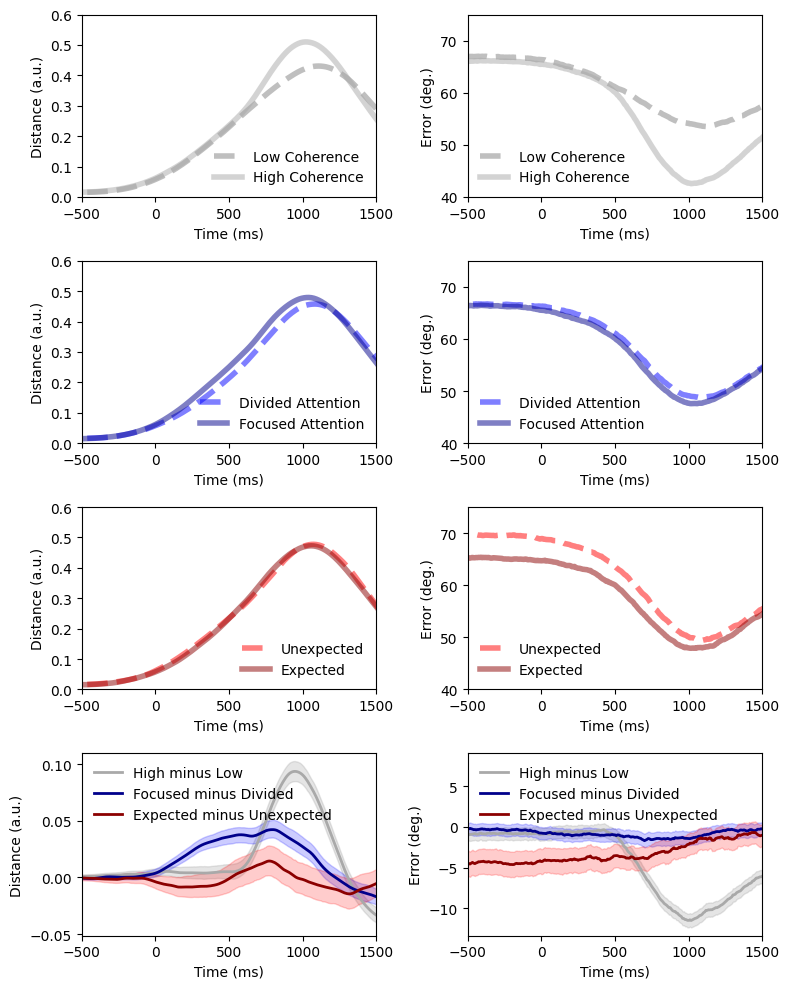

In [22]:
# Plotting the data
fig, ax = plt.subplots(4,2, figsize=(4*2, 10), dpi=100, sharex=False)

d_ax = ax[:3,0]
e_ax = ax[:3,1]

vals = [d_low, d_high, d_divided, d_focused, d_unexpected, d_expected]

for i in range(6):
    d_ax[i//2].plot(xaxis, np.nanmean(vals[i], axis=0), linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=4)
    d_ax[i//2].set_xlim(-500, 1500)
    d_ax[i//2].set_ylim(0, 0.6)
    d_ax[i//2].legend( loc='lower right', frameon=False)
    d_ax[i//2].set_xlabel("Time (ms)")
    d_ax[i//2].set_ylabel("Distance (a.u.)")


vals = [e_low, e_high, e_divided, e_focused, e_unexpected, e_expected]

for i in range(6):
    e_ax[i//2].plot(xaxis, np.nanmean(vals[i], axis=0), linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=4)
    e_ax[i//2].set_xlim(-500, 1500)
    e_ax[i//2].set_ylim(40, 75)
    e_ax[i//2].legend( loc='lower left', frameon=False)
    e_ax[i//2].set_xlabel("Time (ms)")
    e_ax[i//2].set_ylabel("Error (deg.)")


alpha = 0.2

# Plot d differences:
ax[3, 0].plot(xaxis, d_high.mean(axis=0) - d_low.mean(axis=0), label='High minus Low', color='darkgray', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_coh[:, 0], diff_CI_coh[:, 1], color='gray', alpha=alpha)
ax[3, 0].plot(xaxis, d_focused.mean(axis=0) - d_divided.mean(axis=0), label='Focused minus Divided', color='darkblue', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_att[:, 0], diff_CI_att[:, 1], color='blue', alpha=alpha)
ax[3, 0].plot(xaxis, d_expected.mean(axis=0) - d_unexpected.mean(axis=0), label='Expected minus Unexpected', color='darkred', linewidth=2)
ax[3, 0].fill_between(xaxis, diff_CI_exp[:, 0], diff_CI_exp[:, 1], color='red', alpha=alpha)
# ax[3, 0].set_title('Differences in d')
ax[3, 0].set_xlim(-500, 1500)
ax[3, 0].set_xlabel('Time (ms)')
ax[3, 0].set_ylabel('Distance (a.u.)')
ax[3, 0].legend( loc='upper left', frameon=False)

# Plot e differences:
ax[3, 1].plot(xaxis, e_high.mean(axis=0) - e_low.mean(axis=0), label='High minus Low', color='darkgray', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_coh_e[:, 0], diff_CI_coh_e[:, 1], color='gray', alpha=alpha)
ax[3, 1].plot(xaxis, e_focused.mean(axis=0) - e_divided.mean(axis=0), label='Focused minus Divided', color='darkblue', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_att_e[:, 0], diff_CI_att_e[:, 1], color='blue', alpha=alpha)
ax[3, 1].plot(xaxis, e_expected.mean(axis=0) - e_unexpected.mean(axis=0), label='Expected minus Unexpected', color='darkred', linewidth=2)
ax[3, 1].fill_between(xaxis, diff_CI_exp_e[:, 0], diff_CI_exp_e[:, 1], color='red', alpha=alpha)
# ax[3, 1].set_title('Differences in e')
ax[3, 1].set_xlim(-500, 1500)
ax[3, 1].set_xlabel('Time (ms)')
ax[3, 1].set_ylabel('Error (deg.)')
ax[3, 1].legend( loc='upper left', frameon=False)

plt.tight_layout()
plt.show()
